# 1 Likelihood Based Analysis of the 21-cm Power Spectrum
## a) PCA

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np  
import matplotlib.pyplot as plt
import optuna
import torch
import pickle
import tqdm
import copy
import json
import corner

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from pathlib import Path
from torch import nn, optim

In [2]:
from utils.general import load_splits, set_seed

set_seed(1701)
data_dir = Path("simulations")
raw_data = load_splits(data_dir)

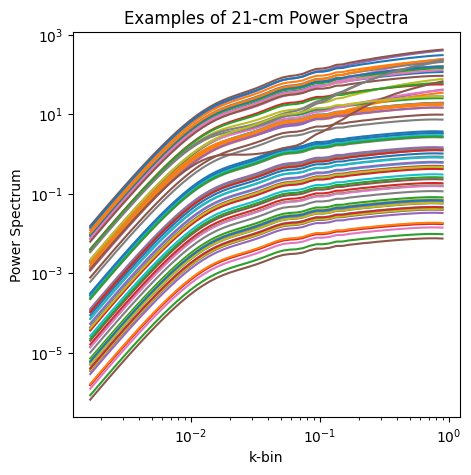

In [128]:
from utils.basic_plots import plot_power_spectra

plot_power_spectra(raw_data)

- We must normalise the training parameters as they can have different scales with respect to one another. We don't want to bias the trained NN based on the various input scales so we can scale them using a StandardScaler, which brings the mean to 0 and variance to 1.
- Each power spectrum mode has a different scale. For PCA, we want to find meaningful variations, not just the largest magnitude variations, which can be a result of different component scales. A component can have little relative variance in its axis but a huge absolute variance because of scale. As such, we normalise our power spectra as well.
- Since the power spectra vary across several orders of magnitude, it is prudent to work with the logarithm.

In [141]:
from utils.preprocess import preprocess
processed = preprocess(raw_data, n_comp=6, log_power=True)

- Now we apply PCA on this data

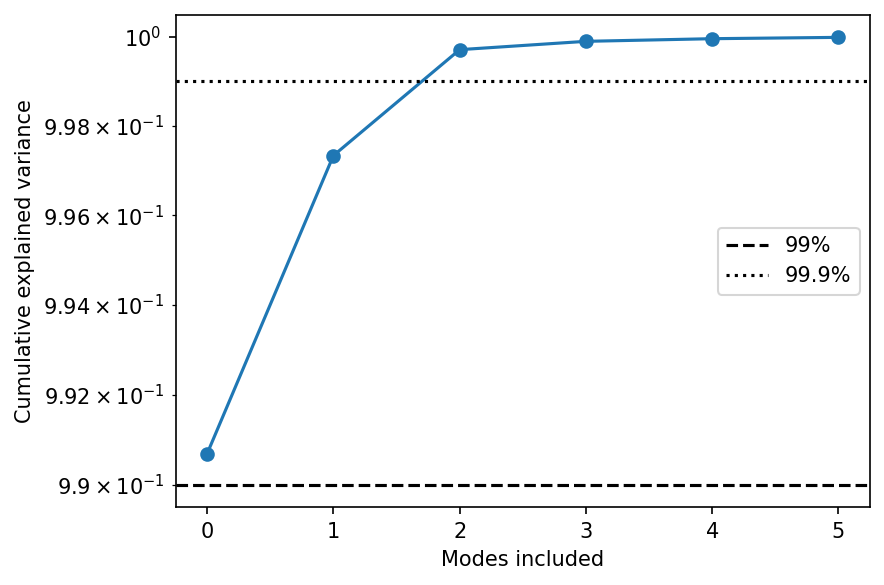

99.000% threshold explained by first 1 components
99.900% threshold explained by first 3 components
99.990% threshold explained by first 5 components


In [142]:
from utils.basic_plots import evr_stats

evr_stats(processed)

- This tells us that the first three eigenvectors are all we need to describe a significant majority of the variance in the data.  It will be valid to compress the training data down using just the first three eigenvectors. 
- However, the explained variance does not correspond directly to emulator accuracy. There are a few more factors to consider:
    - The emulated likelihood may depend on some rare features which only appear in the extremes of some parameter. Because the feature is rare, this leaves a very low variance footprint in the PCA.
    - The emulated likelihood may depend on some small scale feature which looks very small in absolute variance terms.
    - The training set may not be completely representative. Some features appearing in the validation set might not appear here.
- It would not cost too much more to perform the analysis with a few more components for safety.

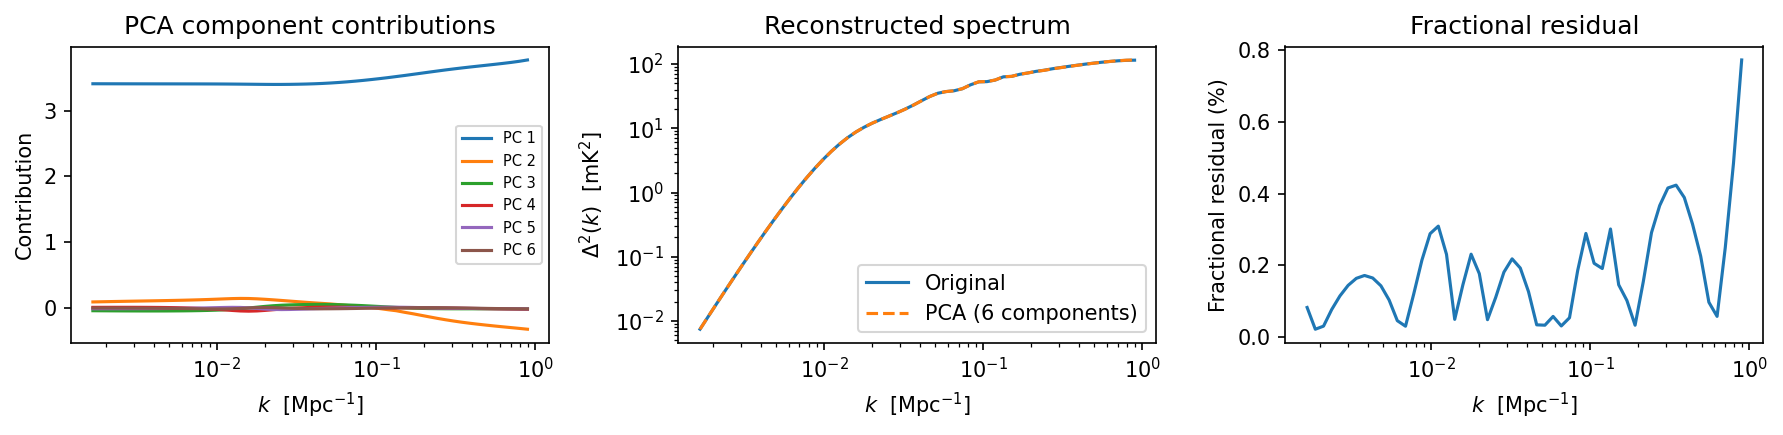

In [143]:
n_comp = 6
from utils.basic_plots import plot_reconstructed_train
_ = plot_reconstructed_train(processed, n_comp=n_comp, plot=True, idx=0)

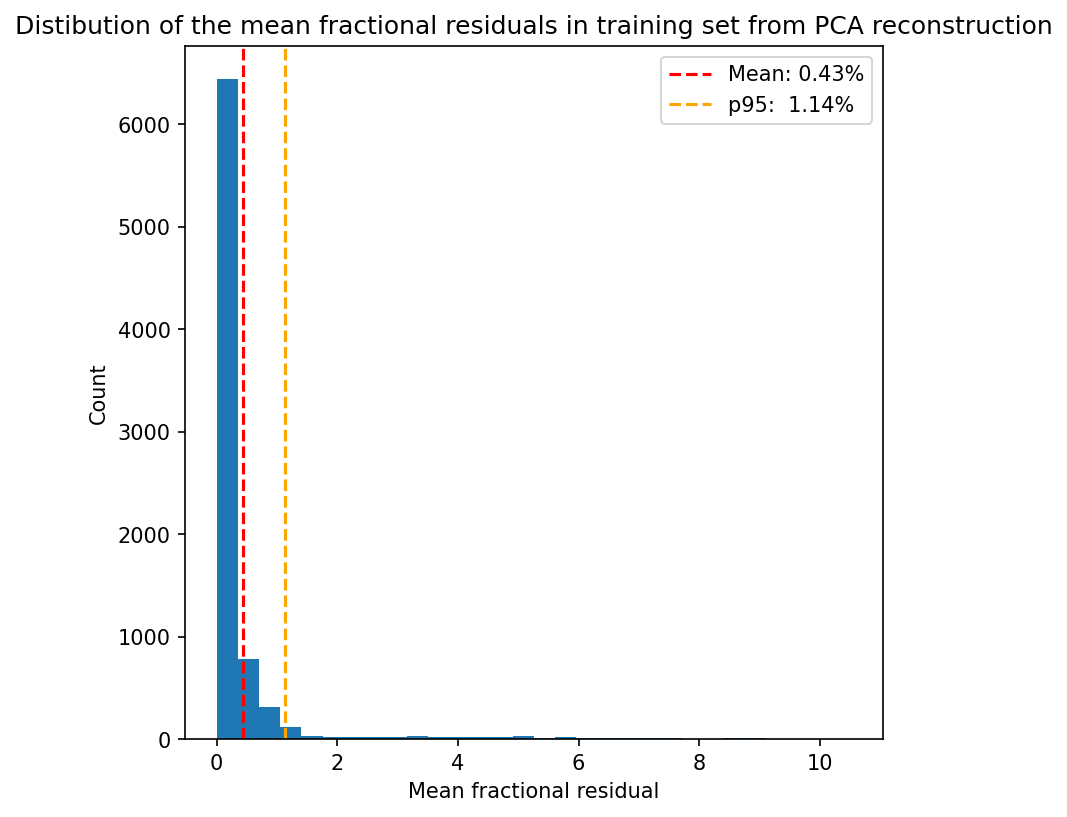

In [146]:
# Plot fractional residual distribution for PCA reconstruction on training set
from utils.basic_plots import pca_fractional_residual
_ = pca_fractional_residual(processed, n_comp=n_comp)

# b) NN 



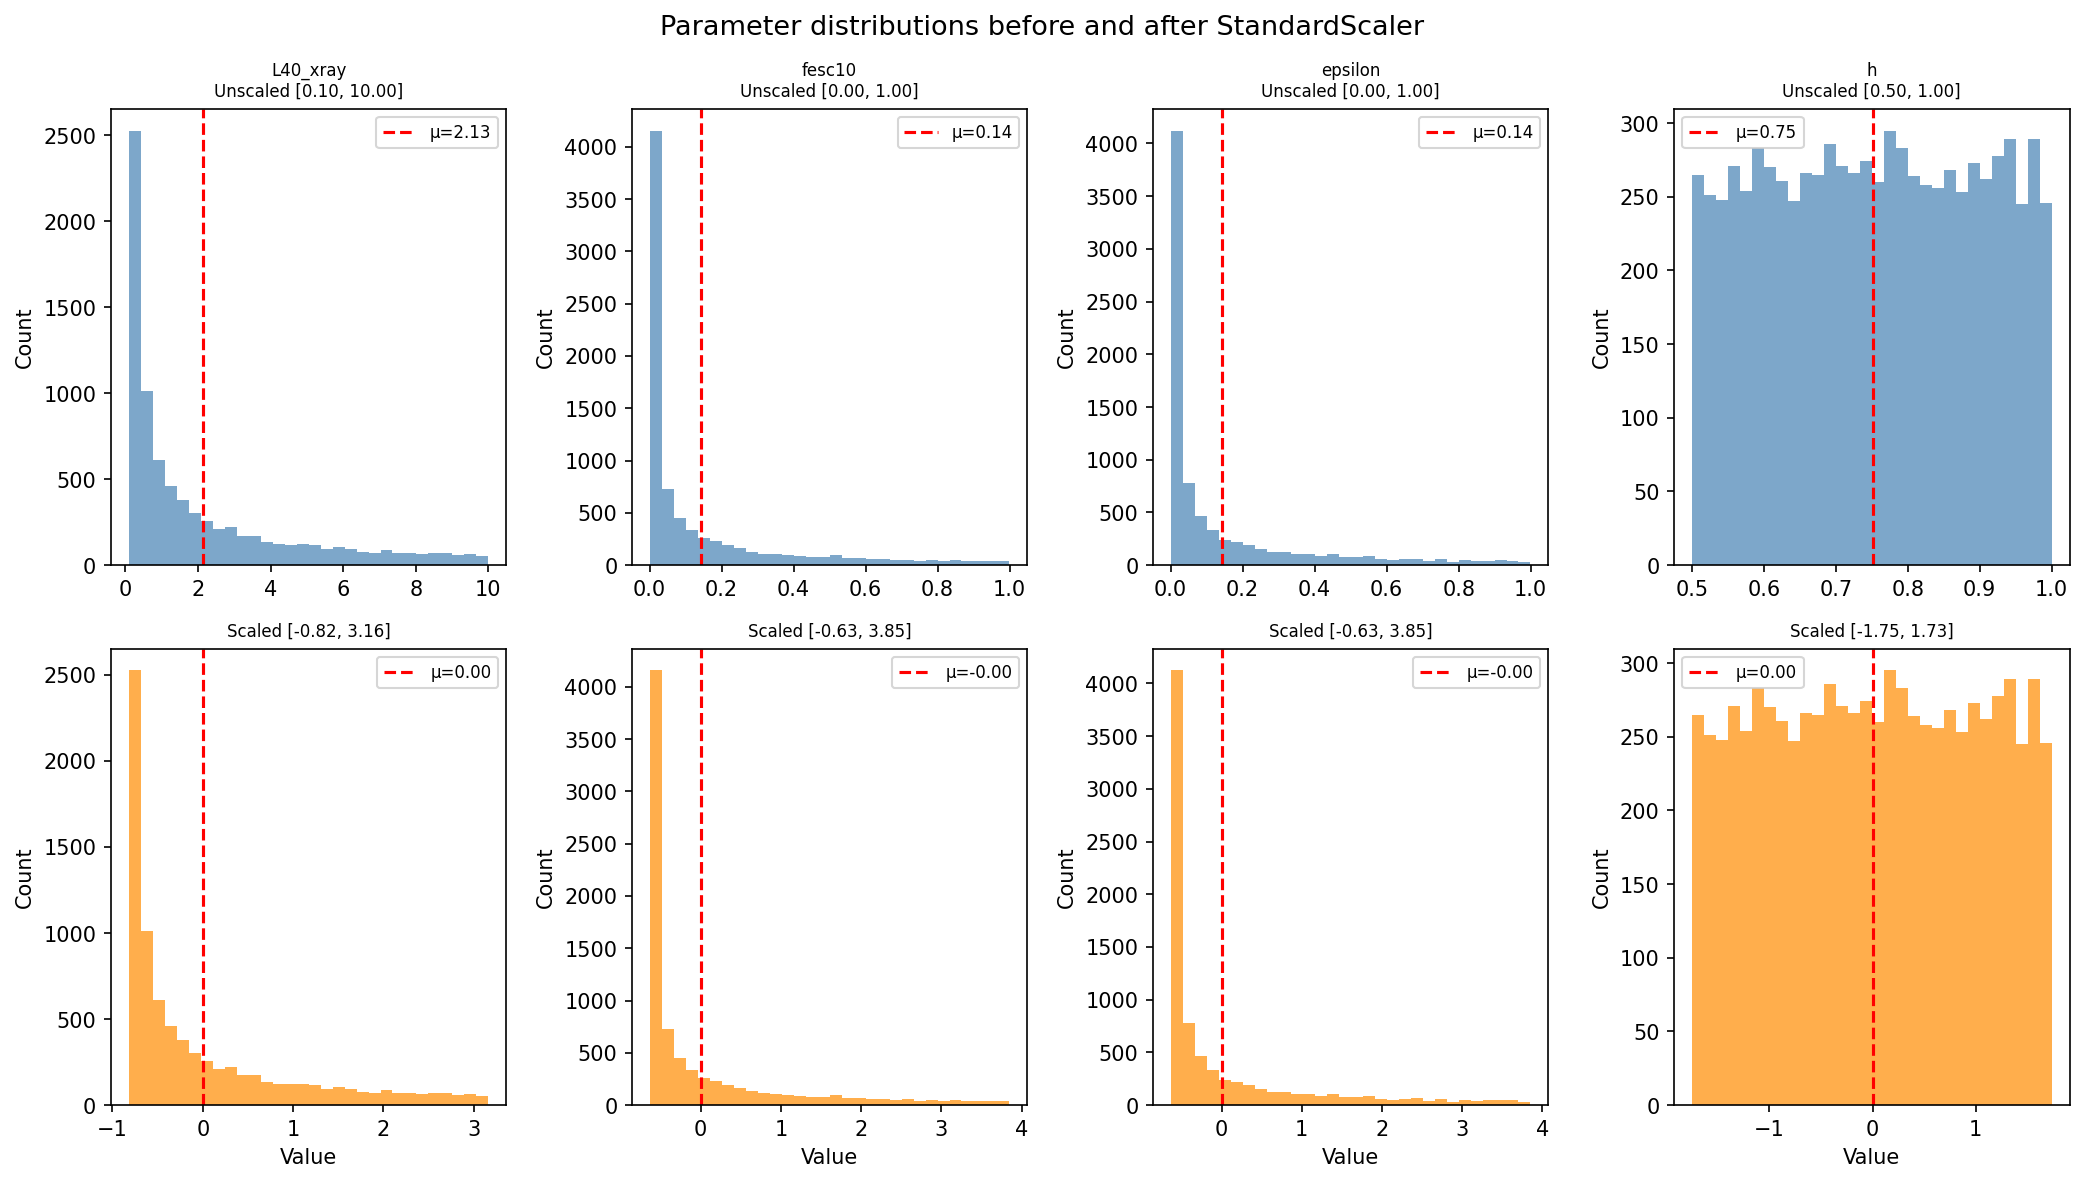

In [155]:
from utils.emulator.plot import plot_pca_train_weights

unscaled_feature_domains =  plot_pca_train_weights(processed,n_comp=n_comp)

- We should normalise each one to to have zero mean and unit variance for best NN performance.

- This looks good. Now we train the NN. 
- We will train a fully connected model. 
- To determine the depth, width, and LR we will use for the model, I will run an optuna optimisation.
- All of this has been shifted to the optuna_optimize_emulator script. It searches through:
    - Number of layers of a dense model between 3 and 10.
    - Hidden dims [32, 64, 128, 256, 512]
    - Learning rate
    - Weight decay regularisation.
- It then retrains the best model and saves it. For more details on the model, please see my report.
- I will just reimport the model here. 

In [159]:
from utils.emulator.emulator import Emulator
from utils.emulator.evaluate_emulator import evaluate_emulator

# Load checkpoint
checkpoint = torch.load("optuna_outputs/local_run/best_model_run50_reconstruction_log_1.65pct.pt", 
                         map_location="cpu")

# Form model
emulator_model = Emulator(
    input_dim=checkpoint["input_dim"],
    output_dim=checkpoint["output_dim"],
    hidden_dim=checkpoint["best_params"]["hidden_dim"],
    num_layers=checkpoint["best_params"]["num_layers"],
)

emulator_model.load_state_dict(checkpoint["model_state_dict"])
emulator_model.eval()

# Load saved model data
with open("optuna_outputs/local_run/preprocessing_run50_reconstruction_log_1.65pct.pkl", "rb") as f:
    preproc = pickle.load(f)

emulator_evaluation_data = evaluate_emulator(emulator_model, processed, device="cpu")
print(f"The model mean frac error is {emulator_evaluation_data['mean_percentage_error']:.2f}%")
print(f"The model 95th percentile frac error is {emulator_evaluation_data['p95_percentage_error']:.2f}%")
print(f"The best parameters are {checkpoint['best_params']}")

The model mean frac error is 1.65%
The model 95th percentile frac error is 5.63%
The best parameters are {'num_layers': 3, 'hidden_dim': 128, 'lr': 0.004860645882927601, 'weight_decay': 1.0535946145298462e-05}


- Now examine emulator_model's performance on the test set.

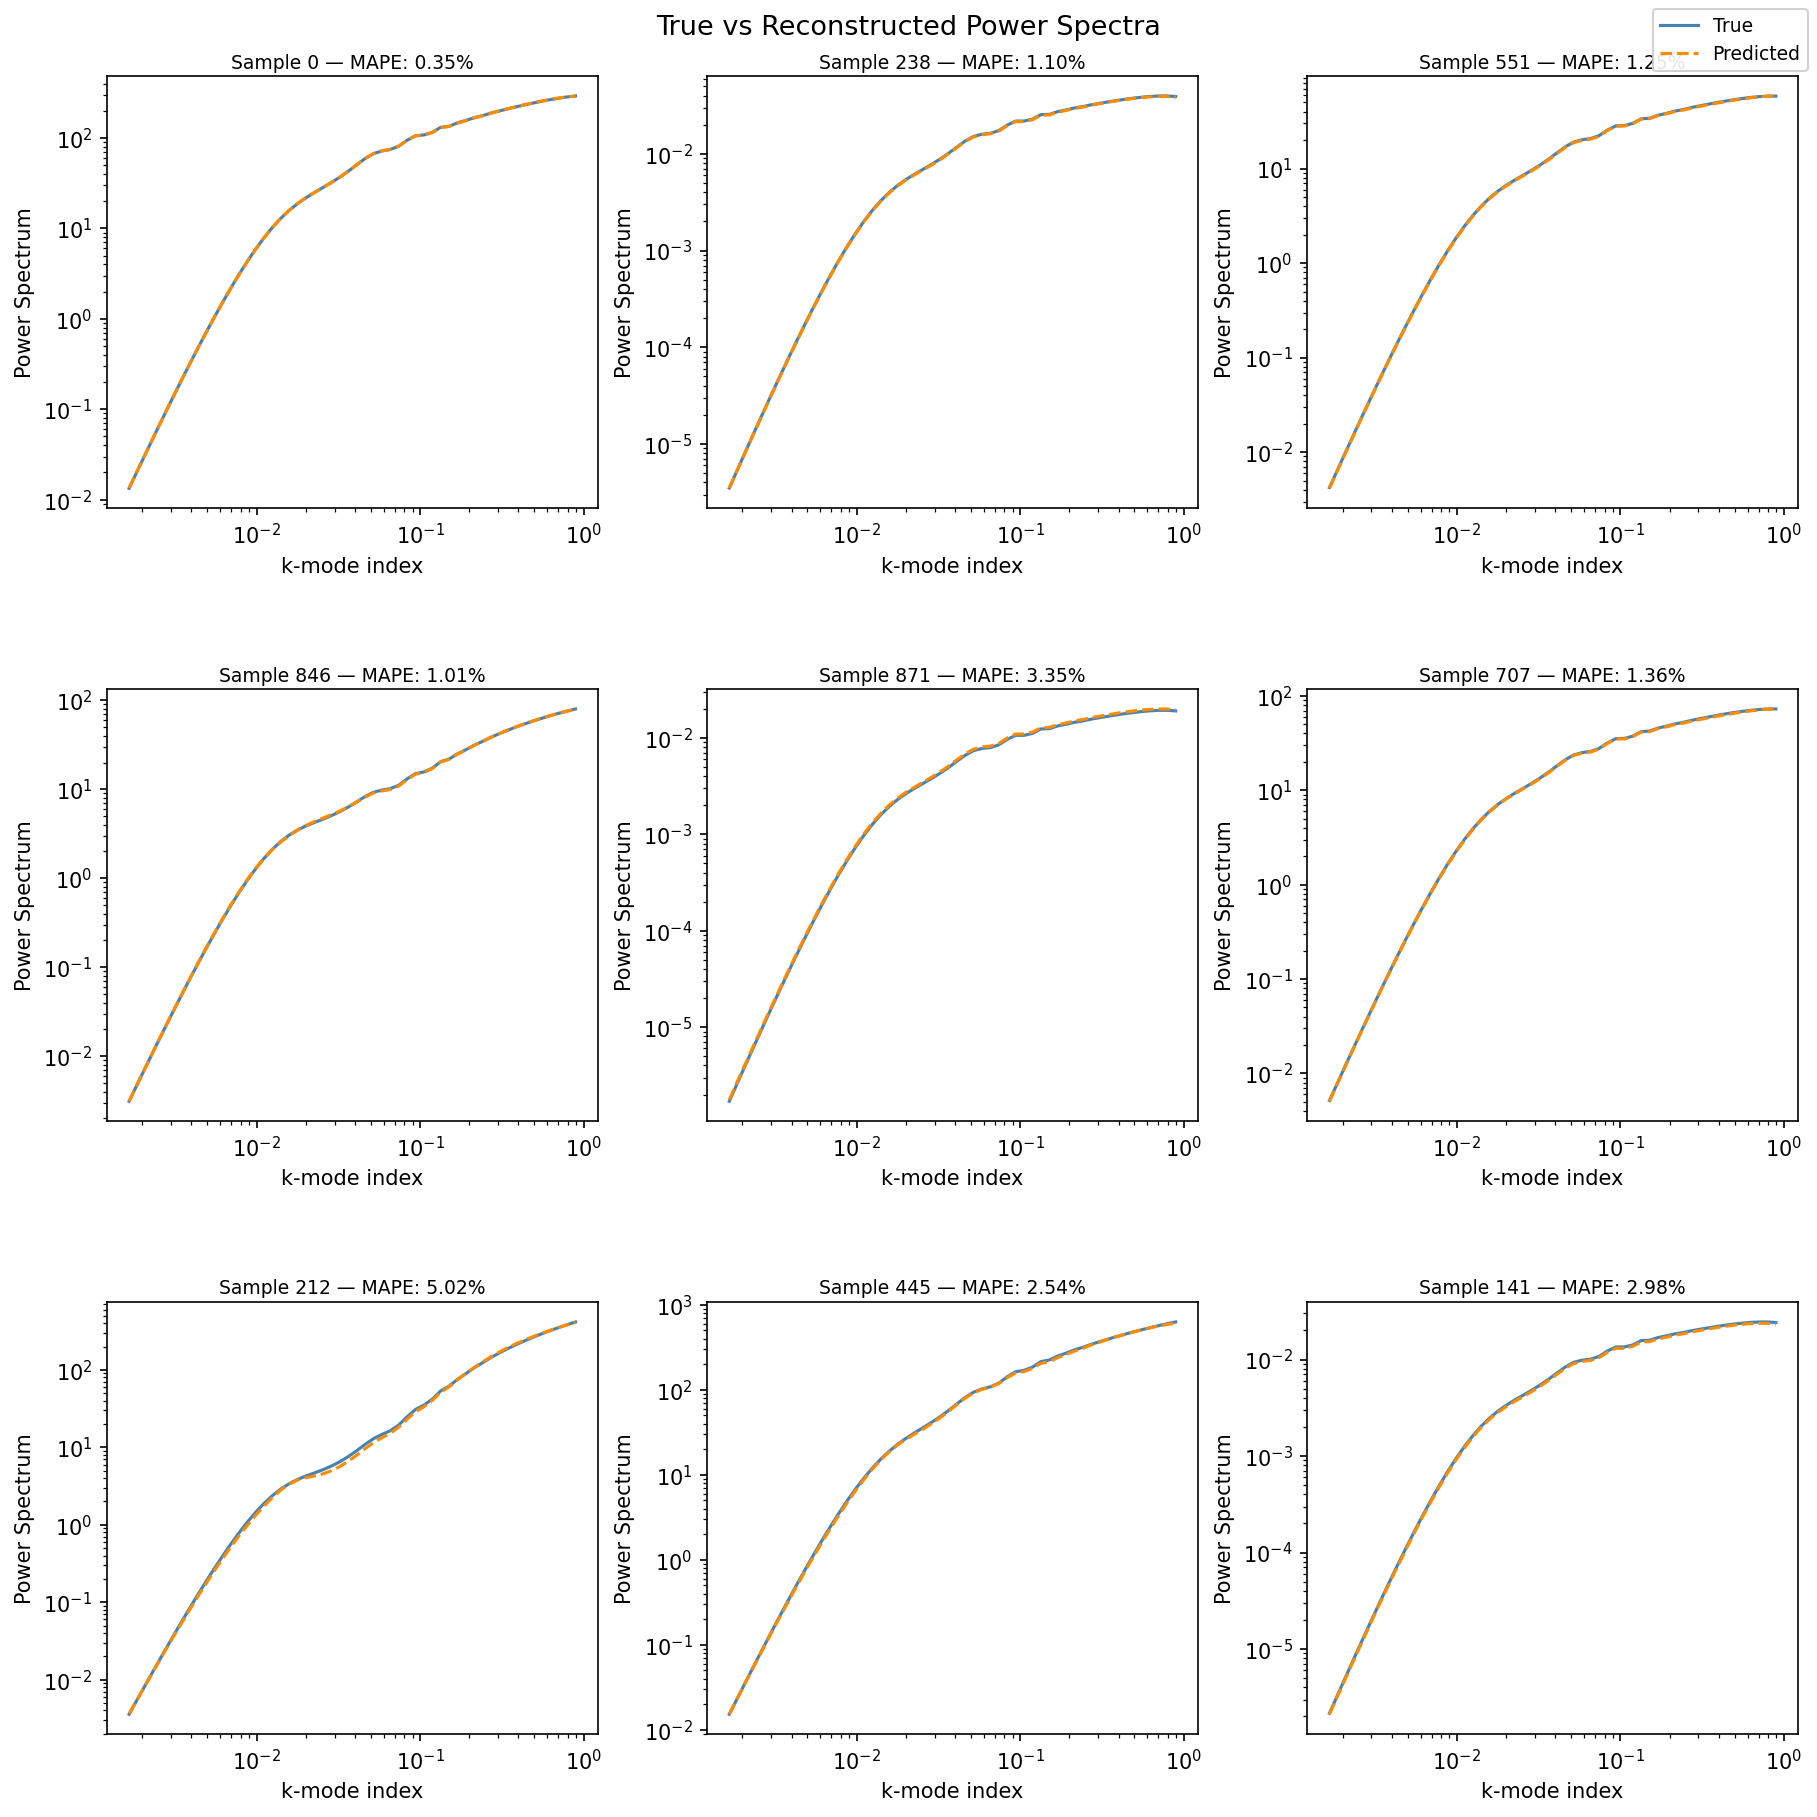

In [164]:
from utils.emulator.plot import plot_emulator_test_reconstructions

plot_emulator_test_reconstructions(emulator_evaluation_data, processed)

This looks great!

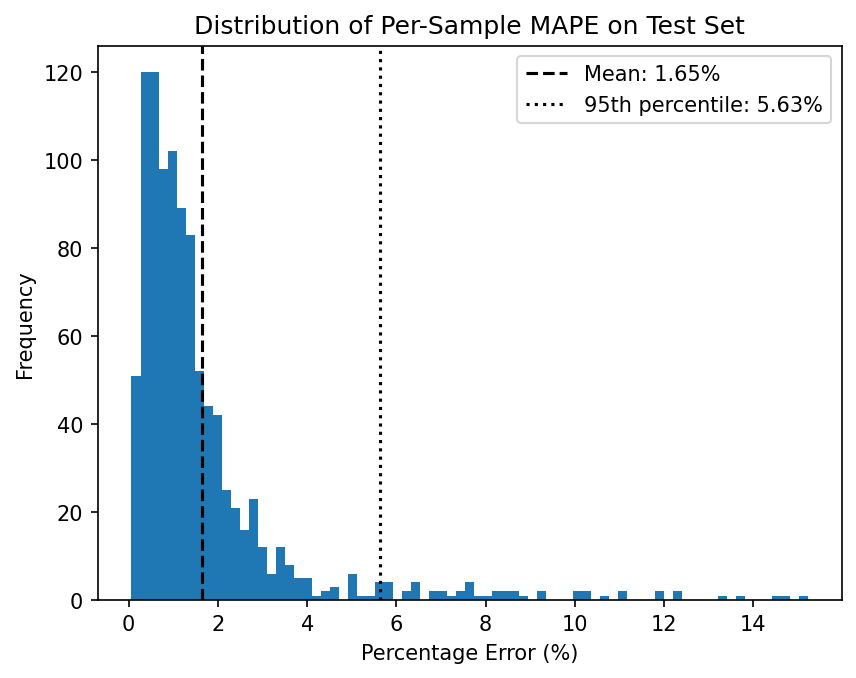

In [165]:
from utils.emulator.plot import plot_mape_distribution

plot_mape_distribution(emulator_evaluation_data)

## c) Sample emulated posterior

In [174]:
# Load the one observation we have... (not very much :<)
observation_path= Path("observations/observations.npz")
with np.load(observation_path, allow_pickle=True) as d:
    observation = dict(d)

In [175]:
# Look at the likelihood input feature domains. Large differences in shape are bad for sampling.
for k, (lo, hi) in unscaled_feature_domains.items():
    print(f"{k}: [{lo:.3g}, {hi:.3g}]  →  {np.log10(hi/lo):.1f} decades")

L40_xray: [0.1, 10]  →  2.0 decades
fesc10: [0.001, 1]  →  3.0 decades
epsilon: [0.001, 1]  →  3.0 decades
h: [0.5, 1]  →  0.3 decades


- The geometry of this is really **nasty**. We can make it simpler by sampling it all in log space.

In [184]:
from utils.mcmc.ensemble import generate_chain,  ln_post_log_emulator

lnspace_ensemble_posterior = generate_chain(
    ln_post_log= ln_post_log_emulator,
    n_walkers=32,
    steps=50000,
    discard=0,
    tf=2,
    unscaled_feature_domains=unscaled_feature_domains,
    model=emulator_model,
    p_obs=observation["power"],
    processed=processed,
    )

100%|██████████| 50000/50000 [11:29<00:00, 72.52it/s]


Mean acceptance fraction: 0.279
Mean autocorrelation time: 642.18 steps


In [185]:
# Save MCMC samples for later analysis
np.save("samples/emcee_emulator_thinned_samples.npy",   np.exp(lnspace_ensemble_posterior["thinned_samples"]))
np.save("samples/emcee_emulator_unthinned_samples.npy", np.exp(lnspace_ensemble_posterior["unthinned_samples"]))
with open("samples/emcee_emulator_diagnostics.json", "w") as f:
    json.dump({
    "mean_frac": float(lnspace_ensemble_posterior["mean_frac"]),
    "taus":      lnspace_ensemble_posterior["taus"].tolist(),
    "mean_tau":  float(lnspace_ensemble_posterior["mean_tau"]),
    "tau":       int(lnspace_ensemble_posterior["tau"]),
    }, f, indent=2)


In [186]:
# Load MCMC samples for analysis
emcee_emulator_thinned_chain = np.load("samples/emcee_emulator_thinned_samples.npy")     # shape (steps, n_walkers, 5)
emcee_emulator_unthinned_chain = np.load("samples/emcee_emulator_unthinned_samples.npy")     # shape (steps, n_walkers, 5)
with open("samples/emcee_emulator_diagnostics.json") as f:
    emcee_emulator_diag = json.load(f)

<Figure size 1200x1200 with 0 Axes>

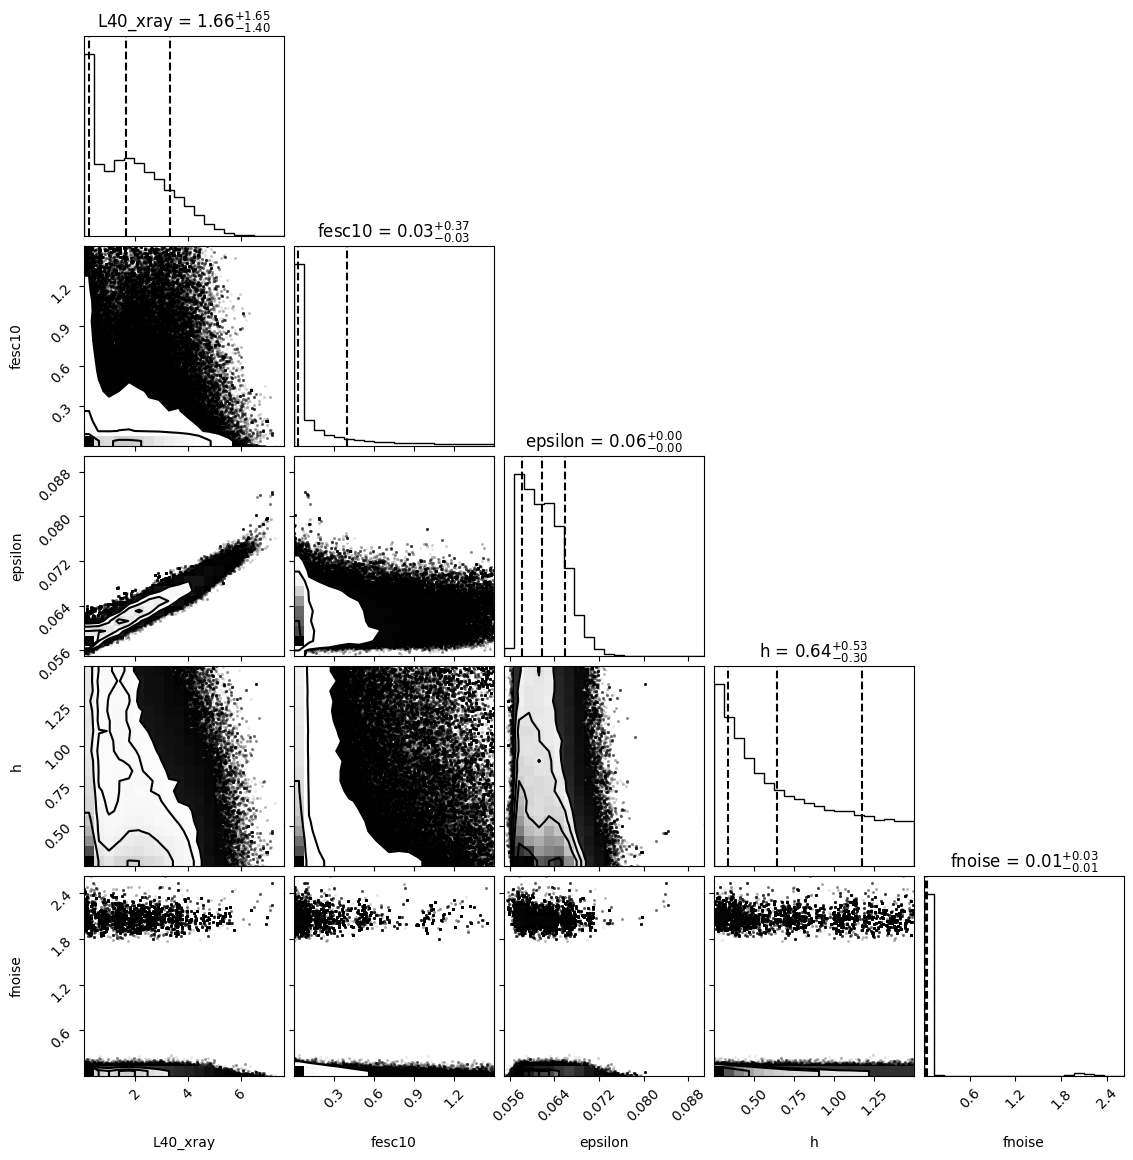

In [188]:
from utils.mcmc.plot import plot_emcee_corner
plot_emcee_corner(
    unthinned_chain=emcee_emulator_unthinned_chain,
    diagnostic=emcee_emulator_diag,
    df = 10
)

In [199]:
from utils.mcmc.nested import build_sampler
nested_emulator_results = build_sampler(emulator_model, processed, observation["power"], unscaled_feature_domains)

23487it [02:54, 134.50it/s, batch: 1 | bound: 4 | nc: 1 | ncall: 432070 | eff(%):  5.018 | loglstar:  2.739 <  5.573 <  4.134 | logz: -2.158 +/-  0.067 | stop:  0.885]                    


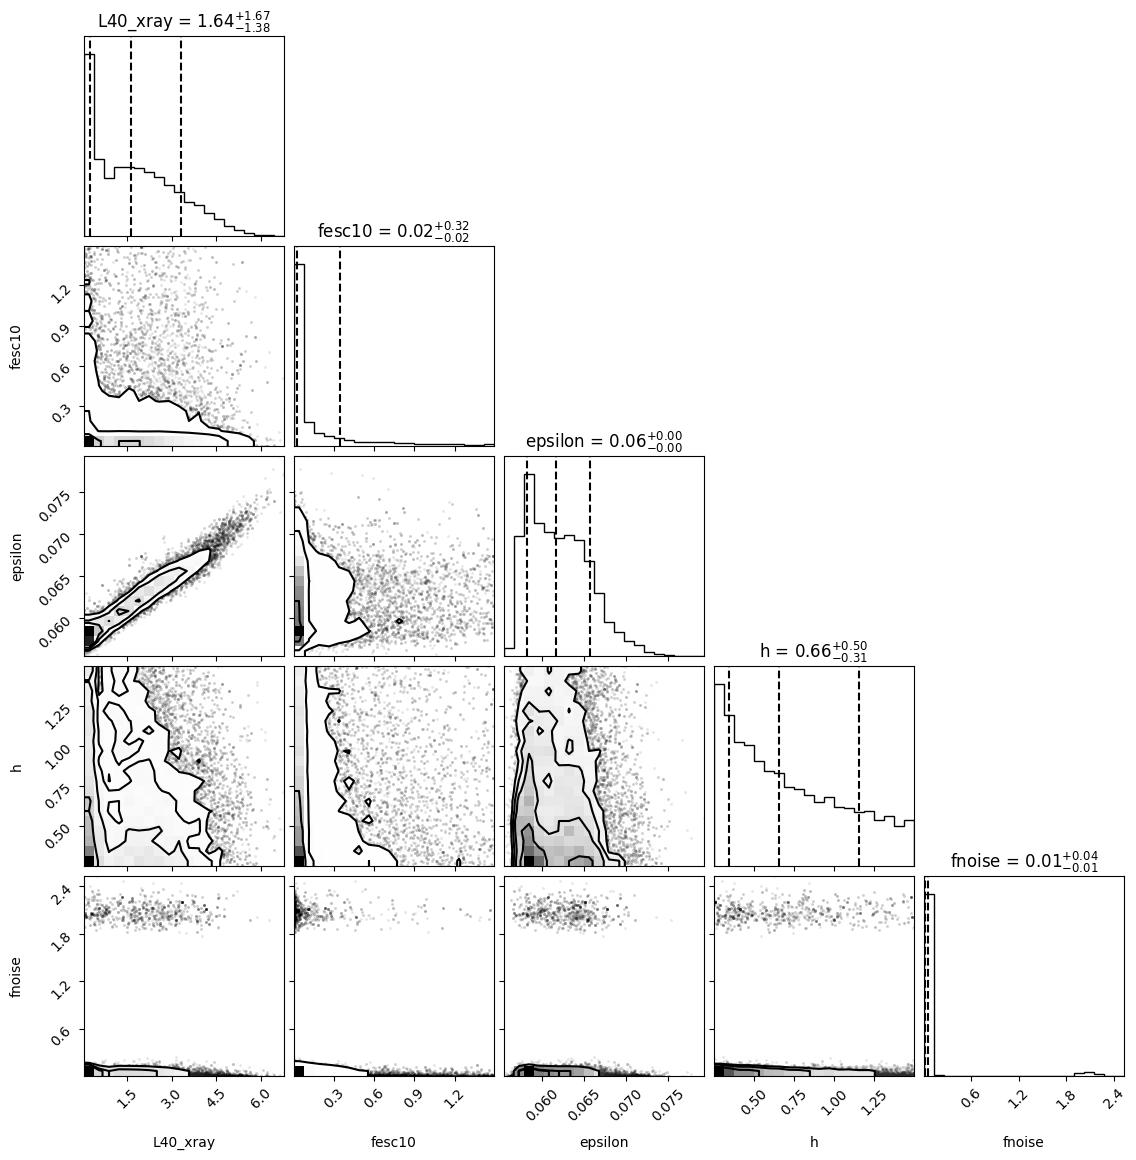

In [200]:
from utils.mcmc.plot import plot_nested_corner
nested_emulator_samples = plot_nested_corner(nested_emulator_results)

- These are both **bad** . But at least they agree ✨✨✨.

# 2)
## a) 
- See report


## b) Draw noisy samples from likelihood


In [194]:
from utils.nre.noise import noisify
n_fnoise
noisy_data = noisify(
    pmodel_train=processed['power_train'],
    pmodel_val=processed['power_val'],
    pmodel_test=processed['power_test'],
    theta4_train=processed['params_train_raw'],
    theta4_val=processed['params_val_raw'],
    theta4_test=processed['params_test_raw'],
    n_fnoise=n_fnoise
)

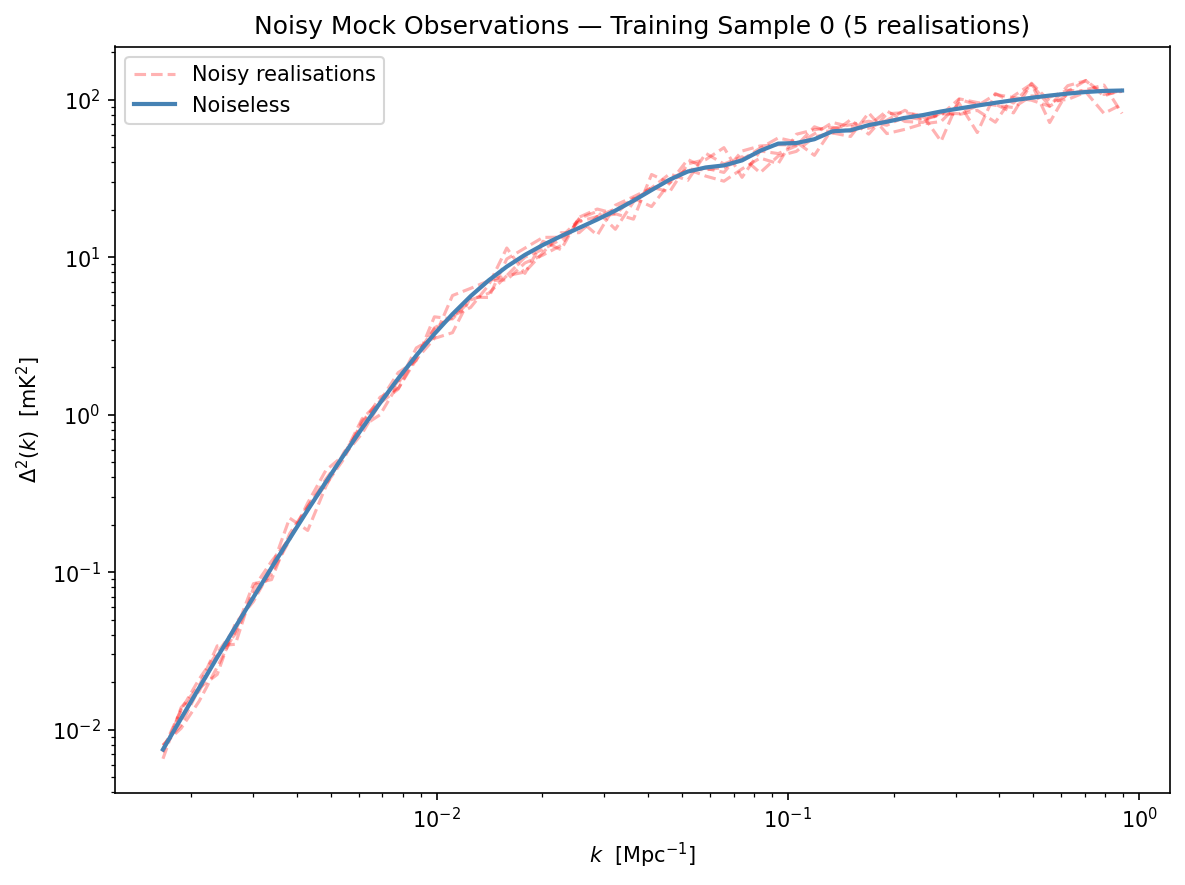

In [202]:
from utils.nre.plot import plot_noisy_data
plot_noisy_data(noisy_data, processed, idx=0, n_fnoise=n_fnoise)

## c)


C:\Users\Joey\Desktop\Cambridge\Work\A1\A1CW\Machine-Learning-Enhanced-Inference-of-the-21-cm-Power-Spectrum-at-Cosmic-Dawn\utils\nre\make_dataset.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  shuffled_idx = np.random.permutation(2*len(pnoisy))


dict_keys(['nre_train', 'nre_val', 'nre_test'])

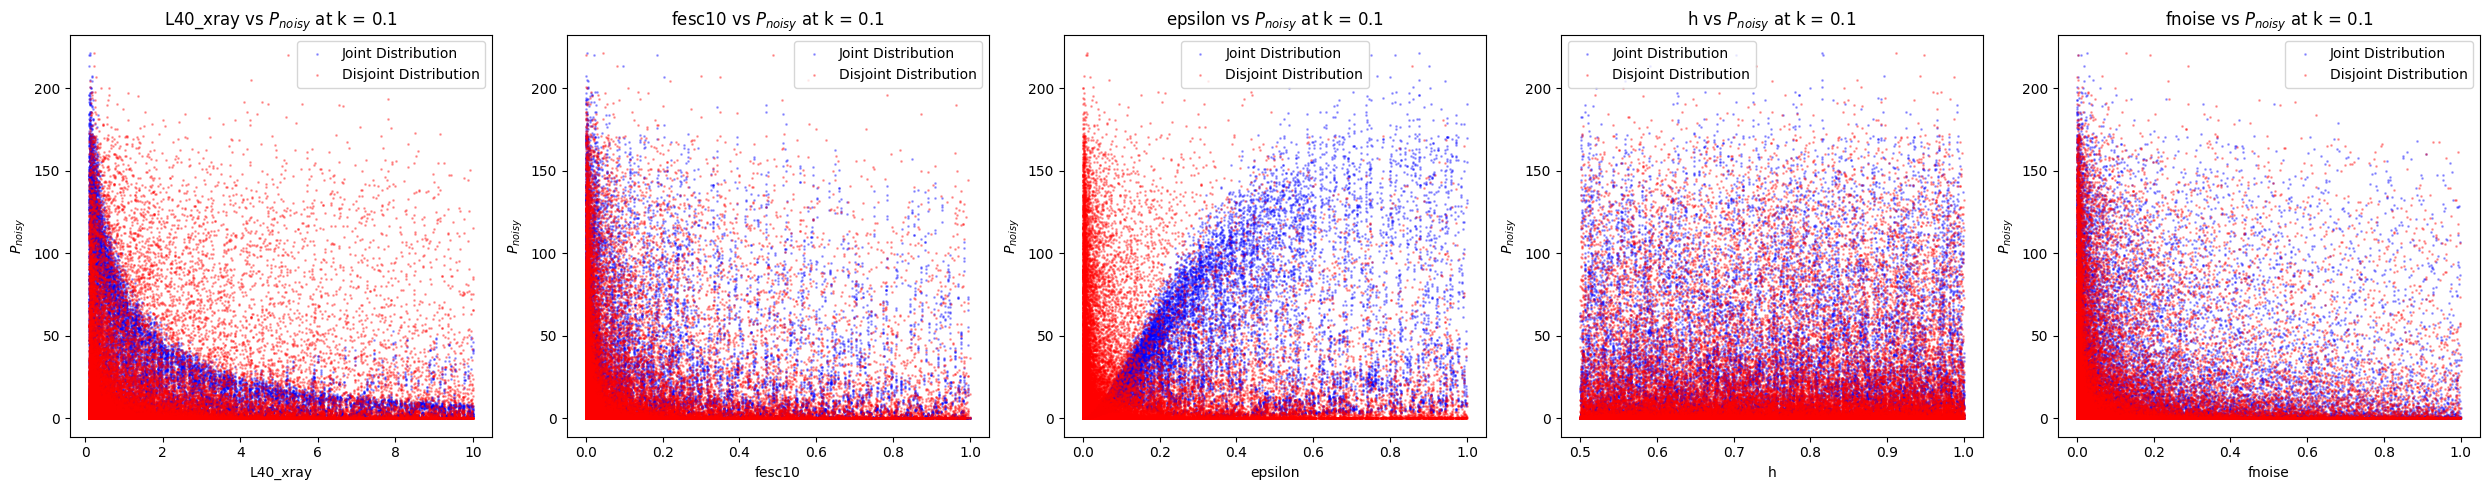

In [205]:
from utils.nre.make_dataset import make_nre_datasets
nre_datasets = make_nre_datasets(noisy_data, processed, plot=True)
nre_datasets.keys()

## d) Build and train NRE

- I managed to get a very good loss from this without a huge optuna run so I will just leave this in here and save the model like before.

Epoch 1/1000 |  train=0.692806 | val=0.692039 
Epoch 101/1000 |  train=0.426873 | val=0.434081 
Epoch 201/1000 |  train=0.351859 | val=0.364213 
Epoch 301/1000 |  train=0.305031 | val=0.320473 
Epoch 401/1000 |  train=0.274046 | val=0.288539 
Epoch 501/1000 |  train=0.247216 | val=0.263220 
Epoch 601/1000 |  train=0.225952 | val=0.241262 
Epoch 701/1000 |  train=0.207445 | val=0.223495 
Epoch 801/1000 |  train=0.191163 | val=0.205550 
Epoch 901/1000 |  train=0.176636 | val=0.192026 
Epoch 1000/1000 |  train=0.164495 | val=0.179563 


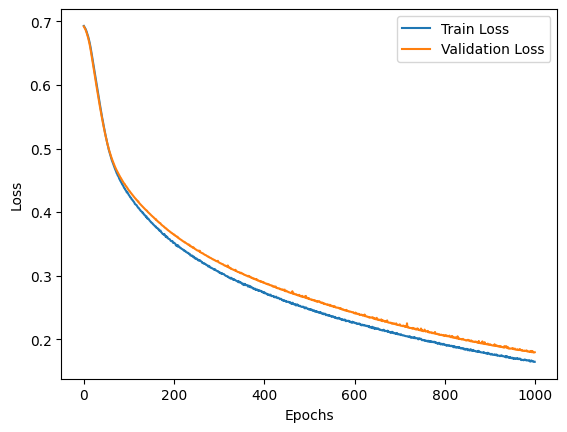

In [208]:
from utils.nre.nre import NRE
from utils.nre.train_nre import train_nre

nre_model = NRE()
best_valid_loss, best_train_loss, best_epoch, trained_nre_model, nre_x_scaler = train_nre(nre_model, nre_datasets['nre_train'], nre_datasets['nre_val'], epochs=1000, batch_size=1024, device='cpu', verbose=True, plot=True, patience=250)

Epoch 1/2000 |  train=0.692239 | val=0.691578 
Epoch 101/2000 |  train=0.422403 | val=0.423130 
Epoch 201/2000 |  train=0.351282 | val=0.358196 
Epoch 301/2000 |  train=0.308731 | val=0.318035 
Epoch 401/2000 |  train=0.278146 | val=0.289309 
Epoch 501/2000 |  train=0.253553 | val=0.265325 
Epoch 601/2000 |  train=0.231571 | val=0.244315 
Epoch 701/2000 |  train=0.215049 | val=0.227832 
Epoch 801/2000 |  train=0.197971 | val=0.211169 
Epoch 901/2000 |  train=0.182533 | val=0.194324 
Epoch 1001/2000 |  train=0.170938 | val=0.182468 
Epoch 1101/2000 |  train=0.159899 | val=0.173813 
Epoch 1201/2000 |  train=0.150202 | val=0.163147 
Epoch 1301/2000 |  train=0.144103 | val=0.154257 
Epoch 1401/2000 |  train=0.135435 | val=0.148319 
Epoch 1501/2000 |  train=0.129281 | val=0.141298 
Epoch 1601/2000 |  train=0.124004 | val=0.137639 
Epoch 1701/2000 |  train=0.118900 | val=0.132677 
Epoch 1801/2000 |  train=0.115360 | val=0.131536 
Epoch 1901/2000 |  train=0.110600 | val=0.126026 
Epoch 2000/2

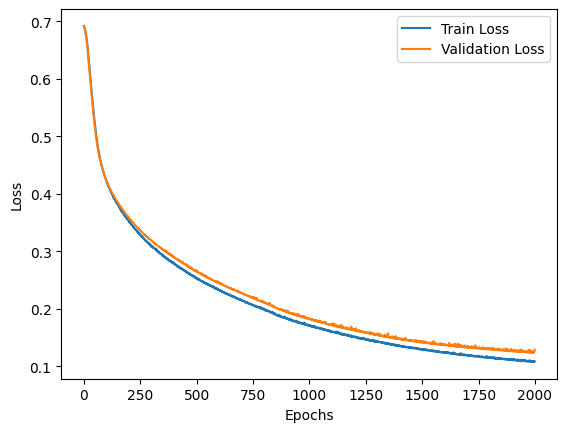

In [ ]:
# nre_model = NRE()
# best_valid_loss, best_train_loss, best_epoch, model, x_scaler = train_nre(nre_model, nre_train, nre_val, epochs=2000)


In [209]:
checkpoint = {
    "model_state_dict": nre_model.state_dict(),
}
torch.save(checkpoint, "saved/nre_checkpoint.pt")

In [210]:
checkpoint = torch.load("saved/nre_checkpoint.pt")
model = NRE()
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

NRE(
  (layers): Sequential(
    (0): Linear(in_features=59, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=100, bias=True)
    (5): ReLU()
    (6): Linear(in_features=100, out_features=1, bias=True)
  )
)

## e) NRE Posterior Sampling

In [ ]:
# from scipy.stats import loguniform

# def _build_priors(unscaled_feature_domains: dict) -> dict:
#     """
#     Construct loguniform prior objects once from feature domains.

#     Call this once before sampling and pass the result to ln_uniform_prior
#     and ln_post_vec so that prior objects are not re-created on every
#     posterior evaluation.

#     Parameters
#     ----------
#     unscaled_feature_domains : dict
#         Dictionary mapping 'epsilon', 'L40_xray', 'fesc10', 'h' to
#         [min, max] physical bounds.

#     Returns
#     -------
#     dict
#         loguniform objects keyed by 'epsilon', 'L40_xray', 'fesc10',
#         'h', and 'fnoise'.
#     """
#     def make(key):
#         lo, hi = unscaled_feature_domains[key]
#         return loguniform(a=0.5 * lo, b=1.5 * hi)

#     return {
#         'epsilon':  make('epsilon'),
#         'L40_xray': make('L40_xray'),
#         'fesc10':   make('fesc10'),
#         'h':        make('h'),
#         'fnoise':   loguniform(a=1e-3, b=1e1),
#     }


# def ln_uniform_prior(L40, fesc10, eps, h, fnoise, priors):
#     """
#     Compute the joint log-prior probability using pre-built prior objects.

#     Parameters
#     ----------
#     L40, fesc10, eps, h, fnoise : float
#         Parameter values.
#     priors : dict
#         Pre-built loguniform objects keyed by 'L40_xray', 'fesc10',
#         'epsilon', 'h', 'fnoise'. Build once with _build_priors().

#     Returns
#     -------
#     float
#         Sum of log-prior probabilities. -inf if any value is outside
#         its prior support.
#     """
#     return (
#         priors['h'].logpdf(h)
#         + priors['epsilon'].logpdf(eps)
#         + priors['L40_xray'].logpdf(L40)
#         + priors['fesc10'].logpdf(fesc10)
#         + priors['fnoise'].logpdf(fnoise)
#     )


In [ ]:
# def nre_ln_post(thetas, priors, scaler, p_obs): # vectorised version
#     n = len(thetas) # thetas is shape (n, 5)
#     results = np.full(n, -np.inf)
#     log_priors = np.zeros(n)
#     valid = np.ones(n, dtype=bool)

#     for i, (L40, fesc10, eps, h, fnoise) in enumerate(thetas):
#         lnPi = ln_uniform_prior(L40=L40, fesc10=fesc10, eps=eps,
#                                 h=h, fnoise=fnoise, priors=priors)
#         if not np.isfinite(lnPi):
#             valid[i] = False
#         else:
#             log_priors[i] = lnPi

#     if not np.any(valid):
#         return results

#     valid_thetas = thetas[valid]                                          # (m, 5)
#     log_p_obs_tiled = np.tile(np.log(p_obs), (len(valid_thetas), 1))    # (m, 54)
#     x_obs_raw = np.concatenate([log_p_obs_tiled, valid_thetas], axis=1) # (m, 59)
#     x_obs = torch.tensor(scaler.transform(x_obs_raw), dtype=torch.float32)

#     with torch.no_grad():
#         lnr = model(x_obs).squeeze(1).cpu().numpy()                      # (m,)

#     results[np.where(valid)[0]] = lnr + log_priors[valid]
#     return results

In [ ]:
from utils.mcmc.ensemble import ln_post_log_nre

nre_data = {"scaler": nre_x_scaler}

lnspace_nre_ensemble_posterior = generate_chain(
    ln_post_log= ln_post_log_nre,
    n_walkers=32,
    steps=500000,
    discard=0,
    tf=2,
    unscaled_feature_domains=unscaled_feature_domains,
    model=nre_model,
    p_obs=observation["power"],
    processed=nre_data,
    )

100%|██████████| 50000/50000 [11:48<00:00, 70.57it/s]


AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 1000;
tau: [ 708.13471678  363.52085331 1105.73731293  510.56005434 1099.58577948]

In [220]:
from utils.mcmc.nested import make_nre_ln_likelihood
nested_nre_results = build_sampler(nre_model, processed= nre_data, p_obs=observation["power"], domains=unscaled_feature_domains, ln_likelihood_fn=make_nre_ln_likelihood)

0it [00:00, ?it/s]c:\Users\Joey\Desktop\Cambridge\Work\A1\A1CW\Machine-Learning-Enhanced-Inference-of-the-21-cm-Power-Spectrum-at-Cosmic-Dawn\VenvA1Cw\lib\site-packages\dynesty\sampler.py:199: RuntimeWarning: overflow encountered in cast
  cur_live_logl[not_finite] = _LOWL_VAL
27301it [02:09, 211.19it/s, batch: 0 | bound: 16 | nc: 1 | ncall: 566062 | eff(%):  4.823 | loglstar:   -inf < 25.362 <    inf | logz: 12.772 +/-  0.077 | dlogz:  0.000 >  0.010] 


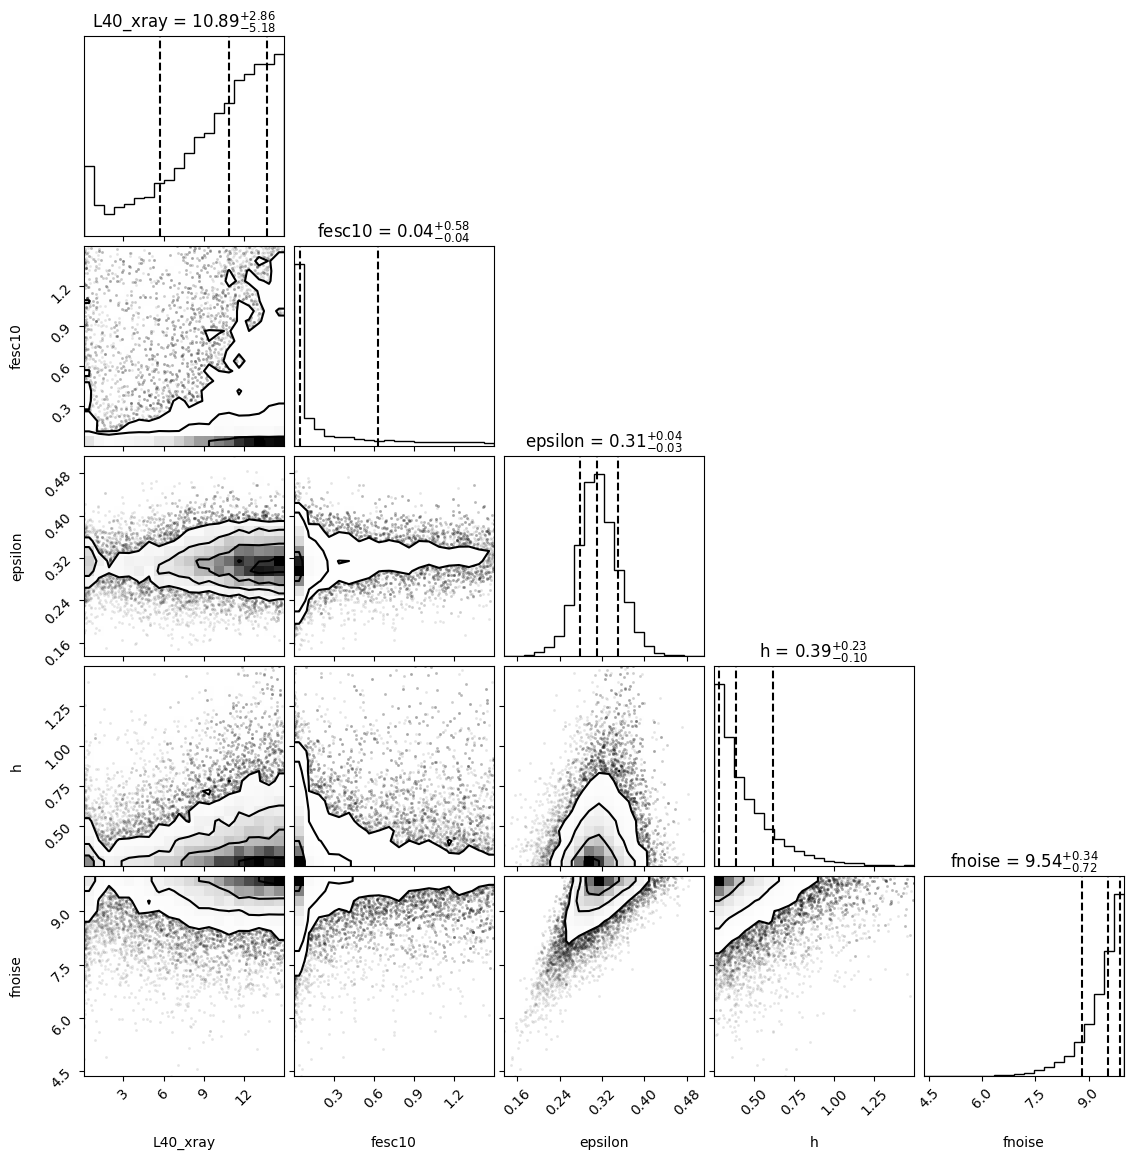

In [221]:
nested_nre_samples = plot_nested_corner(nested_nre_results)